In [1]:
include("CRD_STA.jl")
include("Fun.jl")
using LinearAlgebra
using NonlinearEigenproblems
using DelimitedFiles
using DifferentialEquations
using Plots
using Arpack

In [2]:
function BF(N_cheb,Ro,Tw,Mr)
    gamma = 1.4
    sigma = 0.72
    Co = 2 - Ro - Ro^2
    u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    return F,G,H,T,rho,x,lam,kappa,D,D2
end
function eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
    cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
    L0,L1,L2 = assemble_mat(cof,D,D2,be,omega)
    nep = PEP([L0,L1,L2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-12)
    # eigval = conj(eigval)
    return cof,eigval,eigvec
end
function integral(x,y)
    inte_progress =  zeros(ComplexF64,length(x),1)
    for i = 1 : length(x)
        inte_progress[i] = x[1:i,1]' * y[1:i,1]
    end
    return inte_progress
end
function mat_diff(A,B,N_cheb)
    block_size = N_cheb + 1
    nblock = 5
    C = zeros(ComplexF64,block_size*nblock,block_size*nblock)
    for i = 0 : nblock - 1
        for j = 0 : nblock - 1
        C[1+block_size*i:block_size*(i+1),1+block_size*j:block_size*(j+1)] = (B * A[1+block_size*i:block_size*(i+1),1+block_size*j:block_size*(j+1)])
        end
    end

    return C'
end
function eig_full(eigvec,N_cheb,num)
    N = N_cheb + 1
    eigvec = eigvec[:,num]
    insert!(eigvec,5N-8,0im)
    insert!(eigvec,4N-6,0im)
    insert!(eigvec,4N-6,0im)
    insert!(eigvec,3N-4,0im)
    insert!(eigvec,3N-4,0im)
    insert!(eigvec,2N-2,0im)
    insert!(eigvec,2N-2,0im)
    insert!(eigvec,N,0im)
    insert!(eigvec,N,0im)
    rho = eigvec[1:N]
    u = eigvec[N+1:2N]
    v = eigvec[2N+1:3N]
    w = eigvec[3N+1:4N]
    T = eigvec[4N+1:5N]
    return eigvec,(rho,u,v,w,T)
end

eig_full (generic function with 1 method)

In [3]:
function Bi_linear(C,H1_A,vec_A)
    q_all = []
    for i = 1 : size(C.vectors,2)
        Q = (vec_A') * (H1_A' * C.vectors[:,i])
        q_all = [q_all ; Q]
    end 
    ind = findmax(abs.(q_all))
    Q = q_all[ind[2]]
    return q_all,Q,C.values[ind[2]]
end

Bi_linear (generic function with 1 method)

In [81]:
N_cheb = 199
Ro = -1
Tw = 1.0
Mr = 0.3
gamma = 1.4
sigma = 0.72
Co = 2-Ro-Ro^2
F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)

([0.0; 0.000698485050694182; … ; 6.744959925293321e-24; 6.744959925293321e-24;;], [0.0; -0.0008443020891879594; … ; -1.0; -1.0;;], [-3.176003061707337e-25; -9.579359872977416e-7; … ; -0.884473922139928; -0.884473922139928;;], [1.0; 1.0000115174733584; … ; 0.9999997873656139; 0.9999997873656139;;], [1.0; 0.9999884826592923; … ; 1.0000002126344314; 1.0000002126344314;;], [0.0; 0.0013707944972341864; … ; 40.0; 40.0;;], [-0.6666666666666666; -0.6666743449822389; … ; -0.6666665249104092; -0.6666665249104092;;], [1.3888888888888888; 1.3889048853796644; … ; 1.3888885935633526; 1.3888885935633526;;], [-1200.0454545456726 1459.0921919246277 … -0.09091475537485057 0.045454545454545456; -364.73090422983756 182.3540890834751 … 0.04545495806561524 -0.022726062903512985; … ; 2.7175294799946713e-10 -5.435397634851063e-10 … -2.1805475721239733e-6 4.361366897195741e-6; -0.0 0.0 … -0.0 0.0], [864143.9460754471 -1.3731251765340138e6 … 217.85379665164575 -108.92005707163797; 399125.3504897254 -570715.2166

In [204]:
n = 30
num = 1
R = 300
omega = 0/R
be = n/R
Ma = Mr/R
c = 0.5
cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
L0_raw,L1_raw,L2_raw= assemble_mat(cof,D,D2,be,omega)
L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb)
nep = PEP([L0,L1,L2]);
eigval,eigvec = iar(nep, σ = c, neigs = 1,maxit = 500 , tol=1e-13)
vel_full,vel = eig_full(eigvec,N_cheb,1)

(ComplexF64[4.768004774727589e-9 + 3.5247586998654948e-9im, -1.0860135178332416e-6 + 6.557398071587708e-7im, -4.3586183226063e-6 + 2.6125414309621385e-6im, -9.81376676254417e-6 + 5.874411204002128e-6im, -1.7452061164942992e-5 + 1.0442127586104434e-5im, -2.727178599003376e-5 + 1.63164835822401e-5im, -3.926354959899272e-5 + 2.3497300894673038e-5im, -5.3400198053153423e-5 + 3.198095581310515e-5im, -6.962088159703499e-5 + 4.175520798624941e-5im, -8.780907433347706e-5 + 5.278970353666835e-5im  …  1.0205319933304785e-13 + 1.2896671577888874e-13im, -5.5155939494497264e-14 - 5.0269196357616286e-14im, -8.856640870994956e-15 - 1.040886940441993e-14im, 3.806423085799329e-14 + 3.696327098567931e-14im, 3.164808503154995e-14 + 3.191609303232479e-14im, -1.4778517561726996e-14 - 6.491470772376773e-15im, 1.961148920945058e-14 + 2.1639613770429306e-14im, 4.41522793121961e-14 + 4.653418570494834e-14im, -8.007255849646758e-15 - 7.72966510951625e-15im, 0.0 + 0.0im], (ComplexF64[4.768004774727589e-9 + 3.524

In [6]:
A0_raw = transpose(cof.D1) + (im * be * transpose(cof.B)) - (im * omega * transpose(cof.Ta)) - (be^2 * transpose(cof.Vyy)) - transpose(cof.dC) - (im *be*transpose(cof.dVyz)) + transpose(cof.d2Vzz) - (transpose(cof.C) + im * be * transpose(cof.Vyz) - 2 * transpose(cof.dVzz)) * kron(I(5),D) + transpose(cof.Vzz) * kron(I(5),D2)
A1_raw = (im * transpose(cof.A)) - (be * transpose(cof.Vxy)) - (im * transpose(cof.dVxz)) - (im * transpose(cof.Vxz)) * kron(I(5),D) 
A2_raw = -transpose(cof.Vxx)
L0_A = A0_raw[setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
L1_A = A1_raw[setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
L2_A = A2_raw[setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
nep = PEP([L0_A,L1_A,L2_A]);
eigval_A,eigvec_A = iar(nep,σ = c, neigs = 1 ,maxit = 500,tol = 1e-14)
vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1) 
@show eigval,eigval_A

(eigval, eigval_A) = (ComplexF64[0.5101734811288536 + 0.0027776919470212202im], ComplexF64[0.510173406073695 + 0.0027777409962624045im])


(ComplexF64[0.5101734811288536 + 0.0027776919470212202im], ComplexF64[0.510173406073695 + 0.0027777409962624045im])

In [205]:
A0_raw = transpose(cof.D1) + (-im * be * transpose(cof.B)) - (-im * omega * transpose(cof.Ta)) - (be^2 * transpose(cof.Vyy)) - transpose(cof.dC) - (-im *be*transpose(cof.dVyz)) + transpose(cof.d2Vzz) - (transpose(cof.C) + -1 * im * be * transpose(cof.Vyz) - 2 * transpose(cof.dVzz)) * kron(I(5),D) + transpose(cof.Vzz) * kron(I(5),D2)
A1_raw = (-im * transpose(cof.A)) - (be * transpose(cof.Vxy)) - (-im * transpose(cof.dVxz)) - (-im * transpose(cof.Vxz)) * kron(I(5),D) 
A2_raw = -transpose(cof.Vxx)
L0_A = A0_raw[setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
L1_A = A1_raw[setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
L2_A = A2_raw[setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
nep = PEP([L0_A,L1_A,L2_A]);
eigval_A,eigvec_A = iar(nep,σ = c, neigs = 20 ,maxit = 500,tol = 1e-13)
vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1) 
@show eigval,eigval_A

(eigval, eigval_A) = (ComplexF64[0.5114354748074164 + 0.009495874296230623im], ComplexF64[0.5114355375926368 - 0.009495972161627711im, 0.27603267004099297 - 0.07336044883813675im, 0.5474866020212802 - 0.36555779173883757im, 0.6417219915948472 - 0.4462475315920591im, 0.3979301596541944 - 0.28666180824972187im, 0.2980389902710878 - 0.12321057297559185im, 0.44786008593294296 - 0.29416164157142044im, 0.41541638120834434 - 0.39931687973639596im, 0.7980749250125871 - 0.6810242310981475im, 0.6007621766277025 - 0.6015775799741412im, 0.5790849040065458 - 0.4966529257846931im, 0.829084274380016 - 0.9006378139385804im, 0.6255700583081646 - 0.8120748927321217im, 0.70023265953641 - 0.7281738825065165im, 0.7753900129010391 - 0.9878515350479876im, 0.9588031001099175 - 1.112109386723604im, 0.8135984287739972 - 0.9849851651582611im, 0.0059723129609257075 + 0.331946592064279im, 0.005703219320424113 + 0.3762212623802045im, 0.0058321737045827216 + 0.35352472324568474im])


(ComplexF64[0.5114354748074164 + 0.009495874296230623im], ComplexF64[0.5114355375926368 - 0.009495972161627711im, 0.27603267004099297 - 0.07336044883813675im, 0.5474866020212802 - 0.36555779173883757im, 0.6417219915948472 - 0.4462475315920591im, 0.3979301596541944 - 0.28666180824972187im, 0.2980389902710878 - 0.12321057297559185im, 0.44786008593294296 - 0.29416164157142044im, 0.41541638120834434 - 0.39931687973639596im, 0.7980749250125871 - 0.6810242310981475im, 0.6007621766277025 - 0.6015775799741412im, 0.5790849040065458 - 0.4966529257846931im, 0.829084274380016 - 0.9006378139385804im, 0.6255700583081646 - 0.8120748927321217im, 0.70023265953641 - 0.7281738825065165im, 0.7753900129010391 - 0.9878515350479876im, 0.9588031001099175 - 1.112109386723604im, 0.8135984287739972 - 0.9849851651582611im, 0.0059723129609257075 + 0.331946592064279im, 0.005703219320424113 + 0.3762212623802045im, 0.0058321737045827216 + 0.35352472324568474im])

In [35]:
function Wcc_fun(z,N_cheb)
    Wcc = zeros(N_cheb + 1,N_cheb + 1)
    for i = 1 : 1 : N_cheb
        if i == 1
            Wcc[i,i] = (z[2] - z[1])/2
        elseif i == N_cheb + 1
            Wcc[i,i] = (z[i] - z[i-1])/2
        else
            Wcc[i,i] = (z[i+1] - z[i-1])/2
        end
    end
    W = kron(I(5),Wcc)
    W = W[setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))];
    W_H = kron(I(2),W);
    return W,W_H
end

Wcc_fun (generic function with 1 method)

In [206]:
q_all = []
for i = 1 : length(eigval_A)
    Q = eigvec_A[:,i]' * W  * (L1 + (eigval[1]+eigval_A[i]') * L2) * eigvec[:,1]
    push!(q_all,Q)
end

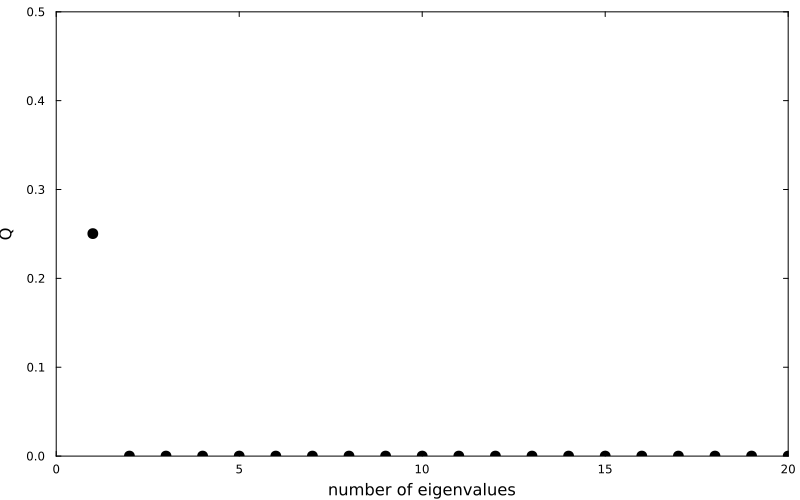

In [207]:
scatter(abs.(q_all),xlims=[0,20],ylims=[0,0.5],size=(800,500),markersize=abs.(6),mc=:black,grid=false,label=false ,framestyle=:box,xlabel="number of eigenvalues", ylabel="Q")

In [ ]:
W,W_H = Wcc_fun(z,N_cheb)
Q = eigvec_A[:,1]' * W  * (L1 + (eigval[1]+eigval_A[1]') * L2) * eigvec[:,1]
abs.(Q)

10×1 Matrix{Float64}:
 0.4275271697503312
 2.059774285022968e-5
 0.00010004734734905276
 0.00025023039207441335
 0.0006146209709788015
 1.3072916486384203e-5
 1.4314260559645387e-5
 0.0011475371135051915
 0.00029031649061333185
 0.00013487903605908104

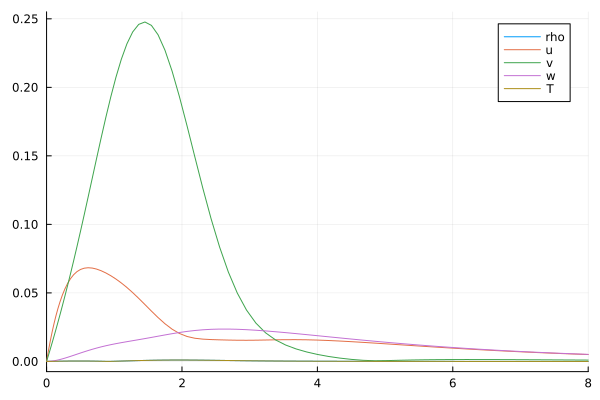

In [102]:
plot(z,abs.(vel[1]),label = "rho",xlims=[0,8]) 
plot!(z,abs.(vel[2]),label = "u",xlims=[0,8])
plot!(z,abs.(vel[3]),label = "v")
plot!(z,abs.(vel[4]),label = "w")
plot!(z,abs.(vel[5]),label = "T") 

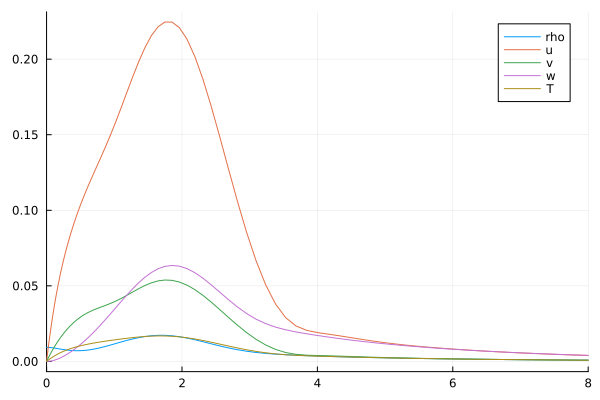

In [103]:
plot(z,abs.(vel_A[1]),label = "rho",xlims=[0,8]) 
plot!(z,abs.(vel_A[2]),label = "u",xlims=[0,8])
plot!(z,abs.(vel_A[3]),label = "v")
plot!(z,abs.(vel_A[4]),label = "w")
plot!(z,abs.(vel_A[5]),label = "T") 

In [13]:
function assemble_adjmat(cof,D,D2,be,omega)
        # A0_raw = transpose(cof.D1) + (im * be * transpose(cof.B)) - (im * omega * transpose(cof.Ta)) - (be^2 * transpose(cof.Vyy)) - transpose(cof.dC) - (im *be*transpose(cof.dVyz)) + transpose(cof.d2Vzz) - (transpose(cof.C) + im * be * transpose(cof.Vyz) - 2 * transpose(cof.dVzz)) * kron(I(5),D) + transpose(cof.Vzz) * kron(I(5),D2)
        # A1_raw = (im * transpose(cof.A)) - (be * transpose(cof.Vxy)) - (im * transpose(cof.dVxz)) - (im * transpose(cof.Vxz)) * kron(I(5),D) 
        # A2_raw = -transpose(cof.Vxx)
        A0_raw = transpose(cof.D1) + (-im * be * transpose(cof.B)) - (-im * omega * transpose(cof.Ta)) - (be^2 * transpose(cof.Vyy)) - transpose(cof.dC) - (-im *be*transpose(cof.dVyz)) + transpose(cof.d2Vzz) - (transpose(cof.C) + -1 * im * be * transpose(cof.Vyz) - 2 * transpose(cof.dVzz)) * kron(I(5),D) + transpose(cof.Vzz) * kron(I(5),D2)
        A1_raw = (-im * transpose(cof.A)) - (be * transpose(cof.Vxy)) - (-im * transpose(cof.dVxz)) - (-im * transpose(cof.Vxz)) * kron(I(5),D) 
        A2_raw = -transpose(cof.Vxx)
    return A0_raw,A1_raw,A2_raw
end
function pre_process(n,R,Mr,OMEGA,N_cheb,c)
    omega = OMEGA/R
    be = n/R
    Ma = Mr/R
    cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
    L0_raw,L1_raw,L2_raw= assemble_mat(cof,D,D2,be,omega)
    L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb)
    A0_raw,A1_raw,A2_raw = assemble_adjmat(cof,D,D2,be,omega)
    L0_A,L1_A,L2_A = boudary_condition(A0_raw,A1_raw,A2_raw,N_cheb)
    nep = PEP([L0,L1,L2]);
    nep = PEP([L0_A,L1_A,L2_A]); 
    eigval,eigvec = iar(nep, σ = c, neigs = 1,maxit = 500 , tol=1e-12)
    vel_full,vel = eig_full(eigvec,N_cheb,1)
    eigval_A,eigvec_A = iar(nep,σ = c, neigs = 1 ,maxit = 500,tol = 1e-14)
    return eigval[1],eigval_A[1]
end


pre_process (generic function with 1 method)

In [ ]:
function eigvec_ref()
    N_cheb = 199
    Ro = -1
    Tw = 1
    Mr = 0.3
    gamma = 1.4
    sigma = 0.72
    Co = 2-Ro-Ro^2
    OMEGA = 0
    F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)
    # for n = 30
    n = 60
        R_start,R_step,R_end = 400,4,500
        num = 1
        data = [0 0 0 0 0 0]
        W,W_H = Wcc_fun(z,N_cheb)
        c,c_A = pre_process(n,R_start,Mr,OMEGA,N_cheb,0.8)
        for R = R_start : R_step : R_end
            omega = 0/R
            be = n/R
            Ma = Mr/R
            cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
            L0_raw,L1_raw,L2_raw= assemble_mat(cof,D,D2,be,omega)
            L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb)
            A0_raw,A1_raw,A2_raw = assemble_adjmat(cof,D,D2,be,omega)
            L0_A,L1_A,L2_A = boudary_condition(A0_raw,A1_raw,A2_raw,N_cheb)

            # H0 = [Zero -eye;L0 L1]
            # H1 = [-eye Zero; Zero -L2]
            # H0_A = [Zero -eye;L0_A L1_A]
            # H1_A = [-eye Zero; Zero -L2_A]
            # C = eigs(H0,H1,nev=1,maxiter = 500,sigma = c, which=:SI)
            # C_A = eigs(H0_A,H1_A,nev=1,maxiter = 500,sigma = c_A, which=:SI)
            # vec_half = C[2][1:5*N_cheb-4,1]
            # vec_A_half = C_A[2][1:5*N_cheb-4,1]
            # vel_full,vel = eig_full(vec_half,N_cheb,1)
            # vel_full_A,vel_A = eig_full(vec_A_half,N_cheb,1)
            # eigval = C[1]
            # eigval_A = C_A[1]
            # c_A =  eigval_A[1]
            # c = eigval[1]

            nep = PEP([L0,L1,L2]);
            nep1 = PEP([L0_A,L1_A,L2_A]); 
            eigval,eigvec = iar(nep, σ = c, neigs = 1,maxit = 500 , tol=1e-12)
            vel_full,vel = eig_full(eigvec,N_cheb,1)
            eigval_A,eigvec_A = iar(nep1,σ = c, neigs = 1 ,maxit = 500,tol = 1e-14)
            c = real(eigval[1])
            vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)
            # data = [data;[R findmax(abs.(vel_A[2]))[1] findmax(abs.((vel_A[3])))[1] findmax(abs.((vel_A[4])))[1]]]
            data = [data ; [R eigval eigval_A (1/R)abs.(D*vel_A[2])[1] (1/R)abs.(D*vel_A[3])[1] (1/R)abs.(D*vel_A[4])[2]]]
            writedlm("log_$(n).dat",data[2:end,:])
        end
    # end
    return data
end
data = eigvec_ref()

In [ ]:
plot(real(data[2:end,1]),real(data[2:end,4]))

In [ ]:
using DelimitedFiles
data_raw = readdlm("log_30.dat")
umax = findmax(data_raw[:,2])[1]
vmax = findmax(data_raw[:,3])[1]
wmax = findmax(data_raw[:,4])[1]
data_raw[:,2] = data_raw[:,2]./umax
data_raw[:,3] = data_raw[:,3]./vmax
data_raw[:,4] = data_raw[:,4]./wmax
writedlm("log_30.dat",data_raw[2:end,:])
plot(real(data_raw[2:end,1]),real(data_raw[2:end,3]))

In [ ]:
function Q_cacu(cof,N_cheb,method,c,c_A)
    L0_raw,L1_raw,L2_raw= assemble_mat(cof,D,D2,be,omega)
    L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb)
    Zero = zeros(size(L0,1),size(L0,2))
    eye = I
    A0_raw = transpose(cof.D1) + (im * be * transpose(cof.B)) - (im * omega * transpose(cof.Ta)) - (be^2 * transpose(cof.Vyy)) - transpose(cof.dC) - (im *be*transpose(cof.dVyz)) + transpose(cof.d2Vzz) - (transpose(cof.C) + im * be * transpose(cof.Vyz) - 2 * transpose(cof.dVzz)) * kron(I(5),D) + transpose(cof.Vzz) * kron(I(5),D2)
    A1_raw = (im * transpose(cof.A)) - (be * transpose(cof.Vxy)) - (im * transpose(cof.dVxz)) - (im * transpose(cof.Vxz)) * kron(I(5),D) 
    A2_raw = -transpose(cof.Vxx)
    A0,A1,A2 = boudary_condition(A0_raw,A1_raw,A2_raw,N_cheb)
    Wcc = zeros(N_cheb + 1,N_cheb + 1)
    for i = 1 : 1 : N_cheb
        if i == 1
            Wcc[i,i] = (z[2] - z[1])/2
        elseif i == N_cheb + 1
            Wcc[i,i] = (z[i] - z[i-1])/2
        else
            Wcc[i,i] = (z[i+1] - z[i-1])/2
        end
    end
    W = kron(I(5),Wcc)
    W = W[setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))];
    W_H = kron(I(2),W);
    if method == 1
        H0 = [Zero -eye;L0 L1]
        H1 = [-eye Zero; Zero -L2]
        H0_A = [Zero -eye;A0 A1]
        H1_A = [-eye Zero; Zero -A2]
        C = eigs(H0,H1,nev=1,maxiter = 500,sigma = c, which=:SI)
        C_A = eigs(H0_A,H1_A,nev=1,maxiter = 500,sigma = c_A, which=:SI)
        vec_half = C[2][1:5*N_cheb-4,1]
        vec_A_half = C_A[2][1:5*N_cheb-4,1]
        vel_full,vel = eig_full(vec_half,N_cheb,1)
        vel_full_A,vel_A = eig_full(vec_A_half,N_cheb,1)
        eigval = C[1]
        eigval_A = C_A[1]
        vec_L = C[2]./findmax(abs.(vel[3]))[1]
        vec_A = C_A[2]./findmax(abs.(vel_A[2]))[1]
        # vec_L = C[2]
        # vec_A = C_A[2]
        W_H = kron(I(2),W);
        vec_half = vec_L[1:5*N_cheb-4,1]
        vec_A_half = vec_A[1:5*N_cheb-4,1]
        vel_full,vel = eig_full(vec_half,N_cheb,1)
        vel_full_A,vel_A = eig_full(vec_A_half,N_cheb,1)
        Q = transpose(vec_A)  *W_H * (H1 * vec_L)
    elseif method == 2
        nep = PEP([L0,L1,L2]);
        eigval,eigvec = iar(nep, σ = c, neigs = 1,maxit = 500 , tol=1e-12)
        vel_full,vel = eig_full(eigvec,N_cheb,1)
        nep1 = PEP([A0,A1,A2]);
        eigval_A,eigvec_A = iar(nep1, σ = c_A, neigs = 1,maxit = 500 , tol=1e-13)
        vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)
        eigvec = eigvec./findmax(abs.(vel[3]))[1]
        eigvec_A = eigvec_A./findmax(abs.(vel_A[2]))[1]
        vel_full,vel = eig_full(eigvec,N_cheb,1)  
        vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)
        Q = (transpose(eigvec_A[:,1]) * W * (L1 + (eigval[1] + eigval_A[1]) * L2) * eigvec[:,1])
    end
    return Q,vel_A,eigval,eigval_A
end

In [221]:
function caculate_cr1()
    N_cheb = 199
    Ro = -1
    Tw = 1.2
    Mr = 0.3
    gamma = 1.4
    sigma = 0.72
    Co = 2-Ro-Ro^2
    num = 1
    F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)
    coff = [0 0 0 0 0 0 0 0 0]
    n = 30
    c = 0.6
    c_A = 0.6
    W,W_H = Wcc_fun(z,N_cheb)
    R_start,R_step,R_end = 300,4,340
    OMEGA = 0
    c,c_A = pre_process(n,R_start,Mr,OMEGA,N_cheb,0.8)
    Zero = zeros(size(L0,1),size(L0,2))
    eye = I
    for R = R_start : R_step : R_end
        omega = OMEGA/R
        be = n/R
        Ma = Mr/R
        hr = 0.2;
        ls =2;  
        
        cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
        L0_raw,L1_raw,L2_raw= assemble_mat(cof,D,D2,be,omega)
        L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb)
        A0_raw,A1_raw,A2_raw = assemble_adjmat(cof,D,D2,be,omega)
        L0_A,L1_A,L2_A = boudary_condition(A0_raw,A1_raw,A2_raw,N_cheb)

        nep = PEP([L0,L1,L2]);
        nep1 = PEP([L0_A,L1_A,L2_A]); 
        eigval,eigvec = iar(nep, σ = c, neigs = 1,maxit = 500 , tol=1e-12)
        vel_full,vel = eig_full(eigvec,N_cheb,1)
        eigval_A,eigvec_A = iar(nep1,σ = c, neigs = 1 ,maxit = 500,tol = 1e-14)        
        vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)
        c = real(eigval[1])
        eigvec = eigvec./findmax(abs.(vel[3]))[1]
        eigvec_A = eigvec_A./findmax(abs.(vel_A[2]))[1]
        vel_full,vel = eig_full(eigvec,N_cheb,1)  
        vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)
        Q = ((eigvec_A[:,1]') * W * (L1 + (eigval[1] + eigval_A[1]') * L2) * eigvec[:,1])

        # H0 = [Zero -eye;L0 L1]
        # H1 = [-eye Zero; Zero -L2]
        # H0_A = [Zero -eye;L0_A L1_A]
        # H1_A = [-eye Zero; Zero -L2_A]
        # C = eigs(H0,H1,nev=1,maxiter = 500,sigma = c, which=:SI)
        # C_A = eigs(H0_A,H1_A,nev=1,maxiter = 500,sigma = c_A, which=:SI)
        # vec_half = C[2][1:5*N_cheb-4,1]
        # vec_A_half = C_A[2][1:5*N_cheb-4,1]
        # vel_full,vel = eig_full(vec_half,N_cheb,1)
        # vel_full_A,vel_A = eig_full(vec_A_half,N_cheb,1)
        # eigval = C[1]
        # eigval_A = C_A[1]
        # c_A =  eigval_A[1]
        # c = eigval[1] 
        # Q = ((eigvec_A[:,1]') * W * (H1) * eigvec[:,1])



        Hx=( hr*exp(-(eigval[1])^2/4 *ls)*sqrt(pi/ls))
        u_wall = -(D*F)[1] *(1/2pi*im) * Hx
        v_wall = -(D*G)[1] *(1/2pi*im) * Hx
        w_wall = 0
        rho_wall = -(D*rho)[1] *(1/2pi*im) * Hx
        T_wall = -(D*T)[1] *(1/2pi*im) * Hx
        item_2 = rho[1] * (D*vel_A[2])[1] * u_wall
        item_3 = rho[1] * (D*vel_A[3])[1] * v_wall
        item_5 = rho[1]^2 * (T[1]/sigma) * (D*vel_A[5])[1] * T_wall
        BC =  item_2 + item_3 + item_5
        Cr = abs(-im * BC/Q[1])
        # coff = [coff;[R Cr real(eigval) imag(eigval) abs(Q[1]) abs(BC)]]
        coff = [coff;[n R Cr abs(Q[1]) abs(BC) real(eigval) imag(eigval) real(eigval_A) imag(eigval_A)]]
        writedlm("Cr_lof.dat",coff[2:end,:])
    end
    return coff
end

caculate_cr1 (generic function with 1 method)

In [222]:
coff = caculate_cr1();

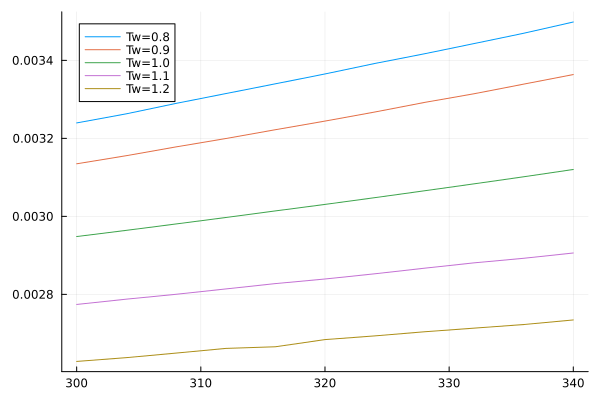

In [223]:
plot!(real(coff[2:end,2]),real(coff[2:end,3]),label = "Tw=1.2")

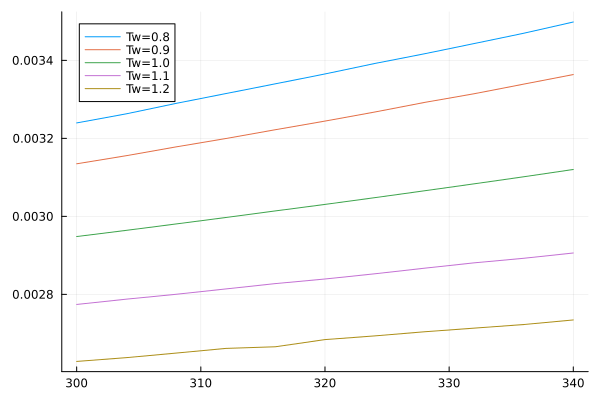

In [224]:
plot!()

In [ ]:
function caculate_cr()
    N_cheb = 199
    Ro = -1
    for Tw in (1.0)
        for Mr in (0.3:0.6)
            gamma = 1.4
            sigma = 0.72
            Co = 2-Ro-Ro^2
            num = 1
            F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)
            coff = [0 0 0 0 0]
            for n = 25 : 1 : 40
                c = c_A = 0.7
                for R = 200 : 2 : 400
                        omega = 0/R
                        be = n/R
                        Ma = Mr/R
                        hr=0.1;
                        ls=5;  
                        cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
                        L0_raw,L1_raw,L2_raw = assemble_mat(cof,D,D2,be,omega)
                        L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb)
                        nep = PEP([L0,L1,L2]);
                        eigval,eigvec = iar(nep, σ = c, neigs = 1,maxit = 500 , tol=1e-12)
                        c = real(eigval[1])
                        vel_full,vel = eig_full(eigvec,N_cheb,1)
                        
                        A0 = transpose(cof.D1) + (im * be * transpose(cof.B)) - (im * omega * transpose(cof.Ta)) - (be^2 * transpose(cof.Vyy)) - transpose(cof.dC) - (im *be*transpose(cof.dVyz)) + transpose(cof.d2Vzz) - (transpose(cof.C) + im * be * transpose(cof.Vyz) - 2 * transpose(cof.dVzz)) * kron(I(5),D) + transpose(cof.Vzz) * kron(I(5),D2)
                        A1 = (im * transpose(cof.A)) - (be * transpose(cof.Vxy)) - (im * transpose(cof.dVxz)) - (im * transpose(cof.Vxz)) * kron(I(5),D) 
                        A2 = -transpose(cof.Vxx)
                        L0_A,L1_A,L2_A = boudary_condition(A0,A1,A2,N_cheb)
                        nep1 = PEP([L0_A,L1_A,L2_A]);
                        eigval_A,eigvec_A = iar(nep1, σ = c_A, neigs = 1,maxit = 500 , tol=1e-14)
                        c_A = real(eigval_A[1])
                        vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)
                        # eigvec = eigvec./findmax(abs.(vel[3]))[1]
                        # eigvec_A = eigvec_A./findmax(abs.(vel_A[2]))[1]
                        vel_full,vel = eig_full(eigvec,N_cheb,1)  
                        vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)

                        Hx=( hr*exp(-(eigval[1])^2/4 *ls^2)*sqrt(pi/ls))
                        u_wall = -(D*F)[1] *(1/2pi*im) * Hx
                        v_wall = -(D*G)[1] *(1/2pi*im) * Hx
                        w_wall = 0
                        rho_wall = -(D*rho)[1] *(1/2pi*im) * Hx
                        T_wall = -(D*T)[1] *(1/2pi*im) * Hx
                        item_2 = rho[1] * (D*vel_A[2])[1] * u_wall
                        item_3 = rho[1] * (D*vel_A[3])[1] * v_wall
                        item_5 = rho[1]^2 * (T[1]/sigma) * (D*(vel_A[5]))[1] * T_wall

                        Q = (transpose(eigvec_A[:,1]) * W * (L1 + (eigval[1] + eigval_A[1]) * L2) * eigvec[:,1])
                        BC =  item_2 + item_3 + item_5
                        Cr = abs(-im * BC/Q[1])
                        # coff = [coff;[R Cr real(eigval) imag(eigval) abs(Q[1]) abs(BC)]]
                        coff = [coff;[n R Cr real(eigval) imag(eigval)]]
                        writedlm("Cr_lof_$(Mr)_$(Tw).dat",coff[2:end,:])
                end
            end
        end
    end
end

In [ ]:
caculate_cr()

In [ ]:
plot(real(coff[2:end,2]),real(coff[2:end,3]))
# plot!(real(coff[2:end,1]),abs.(coff[2:end,3]))

In [ ]:
plot(real(coff[2:end,1]),derivative1(real(coff[2:end,2]),0.1))